In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    average_precision_score, roc_auc_score
)


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "train.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "julian3833/jigsaw-toxic-comment-classification-challenge",
    file_path
)

/tmp/ipykernel_365/2561779869.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'jigsaw-toxic-comment-classification-challenge' dataset.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
df.shape

(159571, 8)

In [5]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
df['toxic'].value_counts()

,count
toxic,
0,144277
1,15294


In [7]:
per_tox= df['toxic'].mean()*100
print(f'The percentage of toxic comment = {per_tox.round(2)}%')

The percentage of toxic comment = 9.58%


In [8]:
toxic_percentage = df['toxic'].value_counts(normalize=True)* 100
print(f'{toxic_percentage.round(2)}')

toxic
0    90.42
1     9.58
Name: proportion, dtype: float64


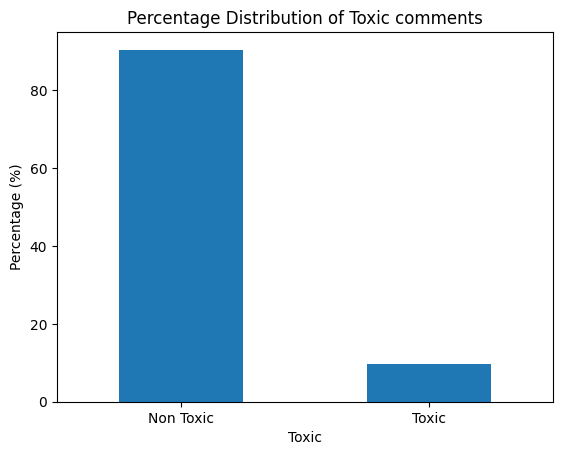

In [9]:
toxic_percentage.plot(kind='bar')

plt.title("Percentage Distribution of Toxic comments")
plt.xlabel("Toxic")
plt.ylabel("Percentage (%)")
plt.xticks([0,1], ['Non Toxic', 'Toxic'], rotation=0)

plt.show()

The dataset is greatly imbalanced and this will affect the way at which our model will learn. IT will most likely see all the comments as non toxic.

In [10]:
df['char_count'] = df['comment_text'].str.len()

In [11]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_count
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67


In [12]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_count
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67


In [13]:
df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))

In [14]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_count,word_count
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13


In [15]:
avg_char_length = df.groupby("toxic")[["char_count", 'word_count']].mean()
print(avg_char_length.round(2))

       char_count  word_count
toxic                        
0          404.55       68.97
1          295.25       51.29


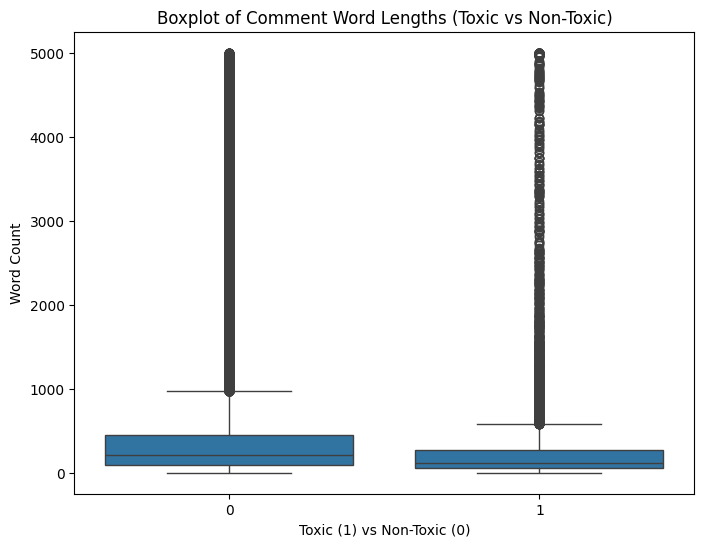

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x="toxic", y="char_count", data=df)
plt.title("Boxplot of Comment Word Lengths (Toxic vs Non-Toxic)")
plt.xlabel("Toxic (1) vs Non-Toxic (0)")
plt.ylabel("Word Count")
plt.show()


Non toxic comments are shorter than toxic comments and this might be due to the fact that some of them are just repeating same thing or confimirming a toxic comment

In [17]:
toxic_comments = df[df["toxic"] == 1]["comment_text"].head(5)

non_toxic_comments = df[df["toxic"] == 0]["comment_text"].head(5)

toxic_comments


,comment_text
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12,Hey... what is it..\n@ | talk .\nWhat is it......
16,"Bye! \n\nDon't look, come or think of comming ..."
42,You are gay or antisemmitian? \n\nArchangel WH...
43,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!"


In [18]:
print("Toxic Comments:\n")
for comment in toxic_comments:
    print("--", comment, "\n")


Toxic Comments:

-- COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK 

-- Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?

Ask Sityush to clean up his behavior than issue me nonsensical warnings... 

-- Bye! 

Don't look, come or think of comming back! Tosser. 

-- You are gay or antisemmitian? 

Archangel WHite Tiger

Meow! Greetingshhh!

Uh, there are two ways, why you do erased my comment about WW2, that holocaust was brutally slaying of Jews and not gays/Gypsys/Slavs/anyone...

1 - If you are anti-semitian, than shave your head bald and go to the skinhead meetings!

2 - If you doubt words of the Bible, that homosexuality is a deadly sin, make a pentagram tatoo on your forehead go to the satanistic masses with your gay pals!

3 - First and last warning, you fucking gay - I won't appreciate if a

In [19]:
print("\nNon-Toxic Comments:\n")
for comment in non_toxic_comments:
    print("--", comment, "\n")


Non-Toxic Comments:

-- Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27 

-- D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC) 

-- Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info. 

-- "
More
I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for

**TOXIC COMMENTS** .The comments that are toxic seems to be against the homosexuality in which the person might be potraying. With words like antisemmitian, homosexuality and gay

**NON TOXIC COMMENT** . The comments seems to be appreciating the the edits. Most of the non toxic comments are not actually appreciating the person the comments are not just toxic. Common words like edit, formatting

**Preprocessing steps** should be: convert all words to lower case, remove tags, special chracter and digits, tokinize words, remove stop words, using lemmer to convert the words bact to their root form because of some words in the comments, handling the imbalance class, vectorization.

There are several things that makes this data set hard for text classification few of them are:
1. **Imbalance class**: If a model simply guesses "Non-Toxic" for every single comment, it would achieve 90% accuracy but be completely useless. So metrics like accuracy are simply useless one has to consider metrics like AUC-ROC or F1-Score rather than raw accuracy.
2. **Multi-Label Complexity**: The data set has a complex label because a sever_toxic comment is still a subset of toxic so a single comment can actually be classified as toxic, super_toxic, insult and obscene.
3. **Intent and context**: Some context are written out of sacrcasm and some people comments some particular words to themselves out of close relationship so some words that are insultive are not actualy insultive or toxic in its contex.
 There are other several things that could affect the training of the model so one needs to handle several possible instances while preprocessing the text.

Metrics like PR-AUC, AUC-ROC and F1-Score should be prirotised.
--
Features like exclamation mark can be pridictive for toxic comments, long length of words can be predictive for non toxic comments

In [20]:
import re
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
class TextPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=True
    ):
        self.lowercase = lowercase
        self.remove_html = remove_html
        self.remove_special = remove_special
        self.remove_stopwords = remove_stopwords
        self.use_lemmatizer = use_lemmatizer

        self.stop_words = set(stopwords.words("english"))
        self.lemmatizer = WordNetLemmatizer()

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        if isinstance(X, pd.Series):
            return X.fillna("").apply(
                self._preprocess_single_text
            )

        return pd.Series([
            self._preprocess_single_text(text)
            for text in X
        ])

    def _preprocess_single_text(self, text):

        text = "" if text is None else str(text)


        if self.remove_html:
            text = re.sub(
                r"<[^>]*>",
                " ",
                text
            )


        if self.lowercase:
            text = text.lower()


        text = re.sub(
            r"http\S+|www\S+",
            " ",
            text
        )


        text = re.sub(
            r"@\w+",
            " ",
            text
        )


        if self.remove_special:
            text = re.sub(
                r"[^a-zA-Z!?'\s]",
                " ",
                text
            )


        text = re.sub(
            r"\s+",
            " ",
            text
        ).strip()


        tokens = word_tokenize(text)


        if self.remove_stopwords:
            tokens = [
                word
                for word in tokens
                if word not in self.stop_words
            ]


        if self.use_lemmatizer:
            tokens = [
                self.lemmatizer.lemmatize(word)
                for word in tokens
            ]

        return " ".join(tokens)

In [23]:
test_preprocessor = TextPreprocessor(
    lowercase=True,
    remove_html=True,
    remove_special=True,
    remove_stopwords=True,
    use_lemmatizer=True
)

sample = df["comment_text"].head().tolist()
sample


["Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",
 "D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)",
 "Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",
 '"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on r

In [24]:
processed_comments = test_preprocessor.fit_transform(sample)


In [25]:
for original, processed in zip(sample, processed_comments):
    print(f"ORIGINAL: {original}")
    print(f"PROCESSED: {processed}\n")


ORIGINAL: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
PROCESSED: explanation edits made username hardcore metallica fan reverted ? n't vandalism closure gas voted new york doll fac please n't remove template talk page since 'm retired

ORIGINAL: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
PROCESSED: d'aww ! match background colour 'm seemingly stuck thanks talk january utc

ORIGINAL: Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.
PROCESSED: hey man 'm really trying edit war 's guy constantly removing relevant informat

# Train/Test Split

In [26]:

X = df['comment_text']
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


nb_pipeline = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=True
    )),
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")


Pipeline fitted successfully!


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [28]:
y_pred = nb_pipeline.predict(X_test)

In [29]:
accuracy =accuracy_score(y_test, y_pred)
print(f"nb model Accuracy: {accuracy:.2}")


nb model Accuracy: 0.92


In [30]:
print("Classification Report of nb model:")
print(classification_report(y_test, y_pred, target_names=['Non-Toxic', 'Toxic']))

Classification Report of nb model:
              precision    recall  f1-score   support

   Non-Toxic       0.92      1.00      0.96     43284
       Toxic       1.00      0.20      0.33      4588

    accuracy                           0.92     47872
   macro avg       0.96      0.60      0.65     47872
weighted avg       0.93      0.92      0.90     47872



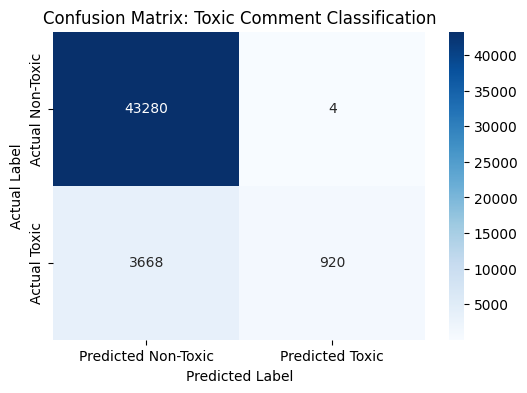

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Toxic', 'Predicted Toxic'],
            yticklabels=['Actual Non-Toxic', 'Actual Toxic'])
plt.title('Confusion Matrix: Toxic Comment Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [32]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=True
    )),
    ('vectorizer', TfidfVectorizer()),
    ('classifier',  LogisticRegression(max_iter=1000))
])


lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('vectorizer', TfidfVectorizer()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [33]:
y_pred_lr = lr_pipeline.predict(X_test)

In [34]:
print("Classification Report of lr model:")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Toxic', 'Toxic']))

Classification Report of lr model:
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.99      0.98     43284
       Toxic       0.92      0.61      0.73      4588

    accuracy                           0.96     47872
   macro avg       0.94      0.80      0.86     47872
weighted avg       0.96      0.96      0.95     47872



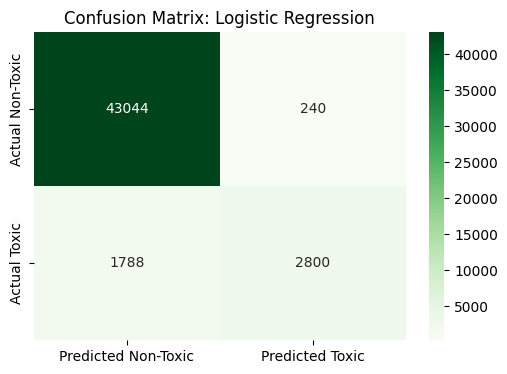

In [35]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Non-Toxic', 'Predicted Toxic'],
            yticklabels=['Actual Non-Toxic', 'Actual Toxic'])
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [36]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

In [37]:
baseline_results = pd.DataFrame([
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Toxic)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Toxic)": recall_score(y_test, y_pred, zero_division=0),
        "F1 (Toxic)": f1_score(y_test, y_pred, zero_division=0),
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision (Toxic)": precision_score(y_test, y_pred_lr, zero_division=0),
        "Recall (Toxic)": recall_score(y_test, y_pred_lr, zero_division=0),
        "F1 (Toxic)": f1_score(y_test, y_pred_lr, zero_division=0),
    }
])


In [38]:
display(
    baseline_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision (Toxic)": "{:.3f}",
        "Recall (Toxic)": "{:.3f}",
        "F1 (Toxic)": "{:.3f}",
    })
)


,Model,Accuracy,Precision (Toxic),Recall (Toxic),F1 (Toxic)
0,Naive Bayes,0.923,0.996,0.201,0.334
1,Logistic Regression,0.958,0.921,0.610,0.734


### Baseline model comparison

The table above is calculated directly from the test-set predictions, so the reported values stay consistent with the models that were actually run.

For this imbalanced problem, the toxic-class **precision, recall and F1-score** are more informative than accuracy alone. Logistic Regression is kept as the main model when it provides the stronger toxic-class F1/recall trade-off.


In [39]:
pipeline_A = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=False,
        use_lemmatizer=True
    )),
    ('vectorizer', TfidfVectorizer()),
    ('classifier',  LogisticRegression(max_iter=1000))
])


pipeline_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor(remove_stopwords=False)),
                ('vectorizer', TfidfVectorizer()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [40]:
pred_A = pipeline_A.predict(X_test)

In [41]:
f1_A = f1_score(y_test, pred_A)

In [42]:
print(f'F1-score without stop words: {f1_A:.2}')

F1-score without stop words: 0.74


In [43]:
pipeline_nlem = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=False
    )),
    ('vectorizer', TfidfVectorizer()),
    ('classifier',  LogisticRegression(max_iter=1000))
])


pipeline_nlem.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor(use_lemmatizer=False)),
                ('vectorizer', TfidfVectorizer()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
pred_nlem = pipeline_nlem.predict(X_test)

In [45]:
f1_nlem = f1_score(y_test, pred_nlem)
print(f'F1-SCORE without lemmatization: {f1_nlem:.2}')


F1-SCORE without lemmatization: 0.73


### Lemmatization experiment

The F1-score above is calculated directly from the model trained without lemmatization. So we will compare it with the baseline Logistic Regression score before deciding whether lemmatization is useful for this dataset.


In [46]:
pipeline_UG = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=True
    )),
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('classifier',  LogisticRegression(max_iter=1000))
])


pipeline_UG.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [47]:
pred_UG = pipeline_UG.predict(X_test)

In [48]:
f1_UG = f1_score(y_test, pred_UG)
print(f'F1-SCORE with unigram and bigram range: {f1_UG:.2}')

F1-SCORE with unigram and bigram range: 0.71


In [49]:
pipeline_TG = Pipeline([
    ('preprocessor', TextPreprocessor(
        lowercase=True,
        remove_html=True,
        remove_special=True,
        remove_stopwords=True,
        use_lemmatizer=True
    )),
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('classifier',  LogisticRegression(max_iter=1000))
])


pipeline_TG.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [50]:
pred_TG = pipeline_TG.predict(X_test)

In [51]:
f1_TG = f1_score(y_test, pred_TG)
print(f'F1-SCORE with unigram and Trigram range: {f1_TG:.3}')

F1-SCORE with unigram and Trigram range: 0.708


In [52]:
experiment_results = pd.DataFrame([
    {"Experiment": "Default Logistic Regression",
     "F1 (Toxic)": f1_score(y_test, y_pred_lr, zero_division=0)},
    {"Experiment": "No Stop Words",
     "F1 (Toxic)": f1_A},
    {"Experiment": "No Lemmatization",
     "F1 (Toxic)": f1_nlem},
    {"Experiment": "Unigram + Bigram",
     "F1 (Toxic)": f1_UG},
    {"Experiment": "Unigram + Bigram + Trigram",
     "F1 (Toxic)": f1_TG},
])

display(experiment_results.style.format({"F1 (Toxic)": "{:.3f}"}))


,Experiment,F1 (Toxic)
0,Default Logistic Regression,0.734
1,No Stop Words,0.737
2,No Lemmatization,0.732
3,Unigram + Bigram,0.706
4,Unigram + Bigram + Trigram,0.708


In [53]:
# ============================================================
# PREPROCESS TRAIN AND TEST DATA ONCE FOR HYPERPARAMETER TUNING
# ============================================================

tuning_preprocessor = TextPreprocessor(
    lowercase=True,
    remove_html=True,
    remove_special=True,
    remove_stopwords=True,
    use_lemmatizer=True
)

print("Preprocessing training data...")

X_train_clean = tuning_preprocessor.fit_transform(
    X_train
)

print("Training data preprocessing complete.")

print("Preprocessing test data...")

X_test_clean = tuning_preprocessor.transform(
    X_test
)

print("Test data preprocessing complete.")

print()
print("Training samples:", len(X_train_clean))
print("Test samples:", len(X_test_clean))

Preprocessing training data...
Training data preprocessing complete.
Preprocessing test data...
Test data preprocessing complete.

Training samples: 111699
Test samples: 47872


In [54]:
tuning_preprocessor = TextPreprocessor(
    lowercase=True,
    remove_html=True,
    remove_special=True,
    remove_stopwords=True,
    use_lemmatizer=True
)


X_train_clean = tuning_preprocessor.fit_transform(
    X_train
)

X_test_clean = tuning_preprocessor.transform(
    X_test
)

print("Test data preprocessing complete.")

print()
print("Training samples:", len(X_train_clean))
print("Test samples:", len(X_test_clean))

Test data preprocessing complete.

Training samples: 111699
Test samples: 47872


In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
tune_pipeline = Pipeline([

    (
        "vectorizer",
        TfidfVectorizer()
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [57]:
param_grid = {
    'vectorizer__max_features': [5000, 10000, 20000],
    'vectorizer__min_df': [1, 2, 5],
    'vectorizer__max_df': [0.5,0.9]
}

In [58]:
grid_search = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=2,
    return_train_score=False
)


In [59]:
from sklearn.model_selection import ParameterGrid

number_of_candidates = len(
    list(ParameterGrid(param_grid))
)

total_fits = number_of_candidates * 3

print(
    "Parameter combinations:",
    number_of_candidates
)

print(
    "Total CV fits:",
    total_fits
)

Parameter combinations: 18
Total CV fits: 54


In [ ]:
grid_search.fit(
    X_train_clean,
    y_train
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    f"Best CV F1 Score: "
    f"{grid_search.best_score_:.4f}"
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=1; total time=   6.0s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=1; total time=   6.1s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=1; total time=   6.0s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=2; total time=   5.9s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=2; total time=   6.2s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=2; total time=   5.2s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=5; total time=   6.4s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=5; total time=   5.4s
[CV] END vectorizer__max_df=0.5, vectorizer__max_features=5000, vectorizer__min_df=5; total time=  

In [ ]:
best_tfidf_params = grid_search.best_params_
best_max_features = best_tfidf_params[
    "vectorizer__max_features"
]

best_min_df = best_tfidf_params[
    "vectorizer__min_df"
]

best_max_df = best_tfidf_params[
    "vectorizer__max_df"
]

print("Best max_features:", best_max_features)
print("Best min_df:", best_min_df)
print("Best max_df:", best_max_df)

In [ ]:
lr_tune_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features= best_max_features, max_df= best_max_df, min_df=best_min_df)),
    ('classifier',  LogisticRegression(max_iter=1000, solver='liblinear', random_state= 42))
])

In [ ]:
param_grid_clf = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

In [ ]:
grid_search_clf = GridSearchCV(
    estimator=lr_tune_pipeline,
    param_grid=param_grid_clf,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=2,
    return_train_score= False
)

In [ ]:
grid_search_clf.fit(
    X_train_clean,
    y_train
)

print(
    "Best Classifier Parameters:",
    grid_search_clf.best_params_
)

print(
    f"Best CV F1 Score: "
    f"{grid_search_clf.best_score_:.4f}"
)

In [ ]:
best_lr_model = grid_search_clf.best_estimator_

best_lr_model

In [ ]:
y_pred_lr = best_lr_model.predict(
    X_test_clean
)

y_prob_lr = best_lr_model.predict_proba(
    X_test_clean
)[:, 1]

In [ ]:
nb_tune_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features= best_max_features, max_df= best_max_df, min_df=best_min_df)),
    ('classifier',  MultinomialNB())
])

param_grid_nb = {
    'classifier__alpha': [0.01, 0.1, 0.5, 1.0]
}

grid_search_nb = GridSearchCV(
    estimator=nb_tune_pipeline,
    param_grid=param_grid_nb,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=2,
    return_train_score=False
)

In [ ]:
grid_search_nb.fit(X_train_clean, y_train)

print(f"Best Naive Bayes Params: {grid_search_nb.best_params_}")
print(f"Best CV F1 Score: {grid_search_nb.best_score_:.4f}")

In [ ]:
best_nb_model = grid_search_nb.best_estimator_
best_nb_model

In [ ]:
y_pred_nb = best_nb_model.predict(
    X_test_clean
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_comparison = pd.DataFrame([
    {
        "Model": "Tuned Naive Bayes",

        "Accuracy": accuracy_score(
            y_test,
            y_pred_nb
        ),

        "Precision": precision_score(
            y_test,
            y_pred_nb,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_nb,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred_nb,
            zero_division=0
        )
    },

    {
        "Model": "Tuned Logistic Regression",

        "Accuracy": accuracy_score(
            y_test,
            y_pred_lr
        ),

        "Precision": precision_score(
            y_test,
            y_pred_lr,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_lr,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred_lr,
            zero_division=0
        )
    }
])

model_comparison

In [ ]:
display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Non-Toxic",
            "Toxic"
        ]
    )
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

pr_auc = average_precision_score(
    y_test,
    y_prob_lr
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

In [ ]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "PR-AUC",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        pr_auc,
        roc_auc
    ]
})

display(
    final_metrics.style.format({
        "Score": "{:.4f}"
    })
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-Toxic",
        "Toxic"
    ],
    yticklabels=[
        "Non-Toxic",
        "Toxic"
    ]
)

plt.title(
    "Tuned Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
thresholds = [
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    threshold_prediction = (
        y_prob_lr >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_prediction,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print(
    f"Best tested threshold based on F1: "
    f"{best_threshold_row['Threshold']:.2f}"
)

print(
    f"F1 Score: "
    f"{best_threshold_row['F1 Score']:.4f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

In [ ]:
vectorizer = best_lr_model.named_steps['vectorizer']
classifier = best_lr_model.named_steps['classifier']

feature_names = vectorizer.get_feature_names_out()

weights = classifier.coef_[0]

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights.round(4)
})

In [ ]:
feature_importance.head(10)

In [ ]:
most_toxic = feature_importance.sort_values(by='Weight', ascending=False).head(20)
None_toxic = feature_importance.sort_values(by='Weight', ascending=True).head(20)

print("Top 20 Most Predictive 'Toxic' Words:")
print(most_toxic)

print("\nTop 20 Most Predictive 'Non_Toxic' Words:")
print(None_toxic)

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='Weight', y='Feature', data=most_toxic, palette='Reds')
plt.title("Top 20 Most Predictive 'Toxic' Words")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.tight_layout()


In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='Weight', y='Feature', data=None_toxic, palette='Blues')
plt.title("Top 20 Most Predictive 'None_Toxic' Words")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.tight_layout()

The classification of the words actually seems fair. The toxic words appears to be toxic words and the non_toxic words are just normal words.

In [ ]:
best_nb_model = grid_search_nb.best_estimator_
vectorizer_nb = best_nb_model.named_steps["vectorizer"]
classifier_nb = best_nb_model.named_steps["classifier"]

feature_names_nb = vectorizer_nb.get_feature_names_out()

# MultinomialNB does not use Logistic Regression-style coefficients.
# A useful class-discriminative score is the difference in log probabilities.
weights_nb = (
    classifier_nb.feature_log_prob_[1]
    - classifier_nb.feature_log_prob_[0]
)


In [ ]:
feature_importance_nb = pd.DataFrame({
    "Feature": feature_names_nb,
    "Log Probability Difference": weights_nb
})


In [ ]:
feature_importance_nb.head(10)


In [ ]:
most_toxic_nb = feature_importance_nb.sort_values(
    by="Log Probability Difference", ascending=False
).head(20)

most_non_toxic_nb = feature_importance_nb.sort_values(
    by="Log Probability Difference", ascending=True
).head(20)

print("Top 20 Naive Bayes features associated with Toxic comments:")
print(most_toxic_nb)

print("\nTop 20 Naive Bayes features associated with Non-Toxic comments:")
print(most_non_toxic_nb)


In [ ]:
results = pd.DataFrame({
    "text": X_test.reset_index(
        drop=True
    ),

    "actual": y_test.reset_index(
        drop=True
    ),

    "predicted": pd.Series(
        y_pred_lr
    ),

    "toxic_probability": pd.Series(
        y_prob_lr
    )
})

In [ ]:
false_positives = results[
    (results["actual"] == 0)
    &
    (results["predicted"] == 1)
]

false_positives.head(10)

In [ ]:
false_negatives = results[
    (results["actual"] == 0)
    &
    (results["predicted"] == 1)
]

false_negatives.head(10)

In [ ]:
custom_samples = [
    "You are a pathetic loser and should be banned from Wikipedia immediately.", # Clearly Toxic
    "I have updated the citations in the 'History' section to reflect the new findings.", # Clearly Non-Toxic
    "I honestly don't know why you even bother editing this page anymore.", # Borderline/Ambiguous
    "Oh great, another brilliant edit from the smartest person on the internet.", # Sarcasm
    "The kill command in the terminal was used to terminate the background process." # Misclassification Bait (Technical)
]


best_model = grid_search_clf.best_estimator_


preds = best_model.predict(custom_samples)
probs = best_model.predict_proba(custom_samples)


import pandas as pd
test_results = pd.DataFrame({
    'Example Type': ['Toxic', 'Non-Toxic', 'Borderline', 'Sarcasm', 'Technical Bait'],
    'Raw Text': custom_samples,
    'Prediction': ['Toxic' if p == 1 else 'Non-Toxic' for p in preds],
    'Toxic Prob (%)': [round(pr[1] * 100, 2) for pr in probs]
})

print(test_results)

# Saving the Model for Deployment using streamlit

The final Logistic Regression classifier and TF-IDF vectorizer are saved separately. The Streamlit app will apply the same preprocessing steps before calling the vectorizer.


In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)

final_vectorizer = best_lr_model.named_steps["vectorizer"]
final_classifier = best_lr_model.named_steps["classifier"]
best_threshold = float(best_threshold_row["Threshold"])

joblib.dump(final_classifier, "models/hate_speech_detector.joblib")
joblib.dump(final_vectorizer, "models/tfidf_vectorizer.joblib")
joblib.dump(best_threshold,"models/decision_threshold.joblib")

print("Saved:")
print("- models/hate_speech_detector.joblib")
print("- models/tfidf_vectorizer.joblib")
print("- models/decision_threshold.joblib")
